In [1]:
import sys
sys.path.append("../../src/")
from common_imports import *
from scipy.integrate import solve_ivp
from numpy import conj
from numpy import linalg as la
import kibble_zurek as kz
from time import time
from joblib import Parallel, delayed
import numpy as np
import time_evolved_z_correlators as zz
#Load Pauli Matrices
s3,s1,s2 = array([[1,0],[0,-1]],dtype=complex),array([[0, 1],[1,0]],dtype=complex), array([[0,-1j],[1j,0]],dtype=complex)



In [2]:

def g(t,tau,alpha=1):
    """
    Time Dependent g(t) with a potential nonlinearity in quench speed controlled by alpha.
    """
    return 1 - np.sign(t)*abs(t/tau)**(alpha)
#TFIM functions
def a(q,g):
    return g+ cos(q)
def b(q,g):
    return sin(q)
def w(q,g):
    return sqrt(g*g+2*g*cos(q)+1)
def BdG(q,g):
    return -2*(a(q,g)*s3+b(q,g)*s2)
###

def BdG_stationary_evolve(t,U,g,q):
    return -1j*BdG(q,g)@U
       

def evolve_mode(q,g0,gf,t_eval):
    V0 = la.eigh(BdG(q, g0))[1][:, 1]
    sol = solve_ivp(
        BdG_stationary_evolve,
        [t_eval[0], t_eval[-1]],
        V0,
        args=(gf,q),
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
        max_step=0.05,
    )
    return sol.y[0], sol.y[1]

def landau_states(L,g0,gf,t_eval):
    n = np.arange(0, L//2 )
    k = (2 * n + 1) * pi / L

    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(evolve_mode)(q, g0, gf, t_eval) for q in k
    )

    us, vs = map(np.array, zip(*results))

    states = [[us[:, i], vs[:, i], k] for i in range(len(t_eval))]
    return states, t_eval


In [355]:
def GroundStateOverlap(states):
    overlaps = []
    u0,v0,_ = states[0]
    for ui,vi,_ in states:
        overlaps.append( np.prod(np.abs(np.conj(u0)*ui+np.conj(v0)*vi))**2)
    return array(overlaps)

def GS_overlap(states,L,g0):
    overlaps=[]
    u0,v0,_=landau_states(L,g0,g0,array([0,.01]))[0][0]
    for ui,vi,_ in states:
        overlaps.append( np.prod(np.abs(np.conj(u0)*ui+np.conj(v0)*vi))**2)
    return array(overlaps)

def critical_times(gf,n):
    ek = 2*sqrt(gf**2+1)
    n_plot = np.arange(0,n)
    tns = (n_plot+1/2)*pi/ek
    return tns


In [390]:
g0= 1.25
gf = .75
ns = [2,3,4,5,6]
L =100


In [391]:
#Critical Times
tns = critical_times(gf,10)
t_eval = np.linspace(0,tns[-1],300)
#States Generation
states,t_eval= landau_states(L,g0,gf,t_eval)



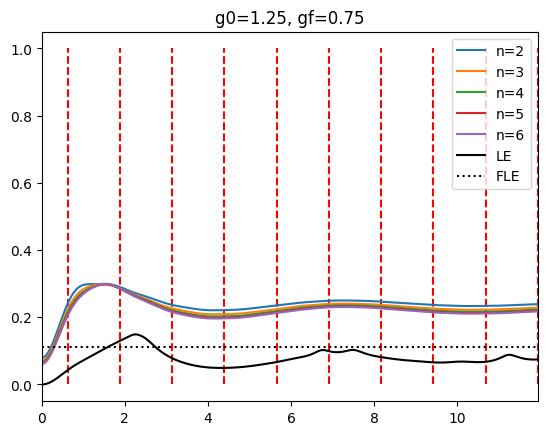

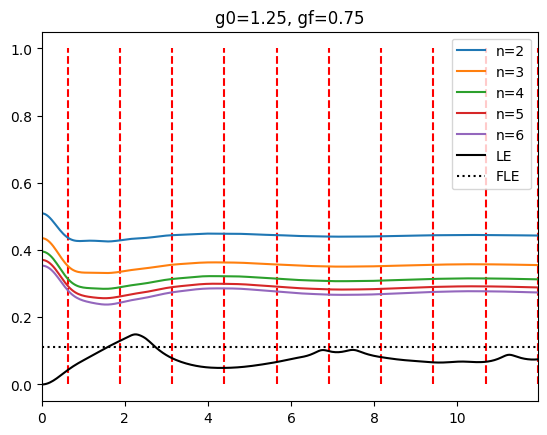

In [392]:
####
#Grab Final States
uf,vf,_=landau_states(L,gf,gf,array([0,.01]))[0][0]
d = GS_overlap(states,L,g0)
f = GS_overlap(states,L,gf)

#Calculate Projections
PZ=array( [
    [-log(zz.P_n(ni,s))/ni for ni in ns] for s in states
] )
PX = array([
    [-log(kz.P_n(ni,s))/ni for ni in ns] for s in states
])

###Plotting###

#### Z projectors ####
for tn in tns:
    plt.vlines(tn,0,1,colors="red",ls="--")
for p,n in zip(PZ.T,ns):
    plot(t_eval,p,label=f"n={n}")
plot(t_eval,-log(d)/L,color="black",label=r"LE")
plot(t_eval,-log(f)/L,color="black",ls=":",label=r"FLE")

title(f"g0={g0}, gf={gf}")
xlim(t_eval[0],t_eval[-1])
legend()

show()
#### X projectors ####
for tn in tns:
    plt.vlines(tn,0,1,colors="red",ls="--")
for p,n in zip(PX.T,ns):
    plot(t_eval,p,label=f"n={n}")
plot(t_eval,-log(d)/L,color="black",label=r"LE")
plot(t_eval,-log(f)/L,color="black",ls=":",label=r"FLE")
title(f"g0={g0}, gf={gf}")
xlim(t_eval[0],t_eval[-1])
legend()

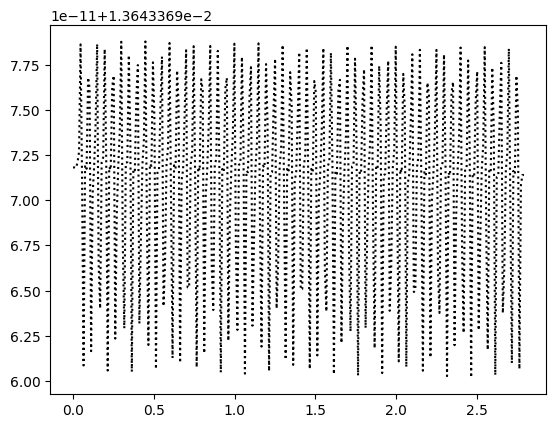

In [384]:
plot(t_eval,f,color="black",ls=":",label=r"FLE")
